# Lifestyle and biomolecular factors on sleep comprehensive regression analysis controlling for any mental health or sleep disorder and excluding individuals using sleep medications or melatonin
# 10-15-2025

In [2]:
import warnings
from arivale_data_interface import get_snapshot
import pandas as pd
import numpy as np
import scipy
import json

warnings.simplefilter("ignore")

#import the final master sleep_merged df and the features_dict

sleep_merged = pd.read_csv('../working_df/sleep_merged_sleep_meds_excluded_10_14_2025.csv', dtype={'public_client_id': object})

with open('../working_df/features_dict.json', 'r') as f:
    features_dict = json.load(f)

In [3]:
!pwd

/proj/gibbons/FitbitSleep_Microbiome/lifestyle_multiomics_sleep_04-01-2026/lifestyle_and_multi-omics_on_sleep_regression_analysis


In [4]:
import sys
import os

# Import my regression and plotting functions python file to use the functions from that
sys.path.append(os.path.abspath("../regression_and_plotting_functions"))
from regression_and_plotting_functions import *

In [5]:
sleep_merged.shape

(1469, 5896)

In [6]:
list(features_dict.keys())

['heartrate_features',
 'activity_features',
 'sleep_features',
 'covariate_features',
 'sleep_features_log1p',
 'sleep_features_log1p_resids',
 'activity_features_resids',
 'heartrate_features_resids',
 'vendor_features',
 'new_microbe_binarized_features',
 'new_microbe_features_binary_10_90',
 'new_microbe_features',
 'diversity_features',
 'dip_features',
 'metabolite_features',
 'food_freq_features',
 'food_freq_features_daily',
 'food_freq_from_non_freq_features',
 'food_freq_from_non_freq_features_daily',
 'diet_daily_features',
 'gut_q_features',
 'mental_health_q_features',
 'sleep_disorder_q_features',
 'digestion_features',
 'supplement_features',
 'med_features',
 'clinical_features',
 'proteomics_features',
 'micom_features',
 'metabolite_features_log',
 'clinical_features_log1p',
 'micom_features_log']

In [7]:
features_dict['vendor_features']

['microbiome_vendor',
 'diet_vendor',
 'mental_health_gut_sleep_q_vendor',
 'digestion_vendor',
 'supp_meds_vendor',
 'clinical_vendor']

In [8]:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip',
 'mental_health_gut_sleep_q_dip',
 'digestion_dip',
 'supp_meds_dip',
 'clinical_dip',
 'proteomics_dip']

# Define the DAG (IV vs DV relationships)

In [9]:
# Define feature groups that show which vendor and/or dip to use in regressions
feature_groups = {
    "fitbit_group": {
        "features": ["sleep_features_log1p_resids"],
        "dip": "fitbit_dip"
    },
    "diet_group": {
        "features": ["diet_daily_features"],
        "dip": "diet_dip"
    },
    "supplements_group": {
        "features": ["supplement_features"],
        "dip": "supp_meds_dip",
        "vendor": "supp_meds_vendor"
    },
    "digestion_group": {
        "features": ["digestion_features"],
        "dip": "digestion_dip",
        "vendor": "digestion_vendor"
    },
    "microbiome_group": {
        "features": ["new_microbe_features", "new_microbe_binarized_features"],
        "dip": "reference_microbe_dip",
        "vendor": "microbiome_vendor"
    },
    "diversity_group": {
        "features": ["diversity_features"],
        "dip": "reference_microbe_dip",
        "vendor": "microbiome_vendor"
    },
    "clinical_group": {
        "features": ["clinical_features_log1p"],
        "dip": "clinical_dip",
        "vendor": "clinical_vendor"
    },
    "metabolite_group": {
        "features": ["metabolite_features_log"],
        "dip": "metabolite_dip"
    },
    "proteome_group": {
        "features": ["proteomics_features"],
        "dip": "proteomics_dip"
    },
    "micom_metab_group": {
        "features": ["micom_features_log"],
        "dip": "reference_microbe_dip",
        "vendor": "microbiome_vendor"
    }
}

In [10]:
feature_groups

{'fitbit_group': {'features': ['sleep_features_log1p_resids'],
  'dip': 'fitbit_dip'},
 'diet_group': {'features': ['diet_daily_features'], 'dip': 'diet_dip'},
 'supplements_group': {'features': ['supplement_features'],
  'dip': 'supp_meds_dip',
  'vendor': 'supp_meds_vendor'},
 'digestion_group': {'features': ['digestion_features'],
  'dip': 'digestion_dip',
  'vendor': 'digestion_vendor'},
 'microbiome_group': {'features': ['new_microbe_features',
   'new_microbe_binarized_features'],
  'dip': 'reference_microbe_dip',
  'vendor': 'microbiome_vendor'},
 'diversity_group': {'features': ['diversity_features'],
  'dip': 'reference_microbe_dip',
  'vendor': 'microbiome_vendor'},
 'clinical_group': {'features': ['clinical_features_log1p'],
  'dip': 'clinical_dip',
  'vendor': 'clinical_vendor'},
 'metabolite_group': {'features': ['metabolite_features_log'],
  'dip': 'metabolite_dip'},
 'proteome_group': {'features': ['proteomics_features'],
  'dip': 'proteomics_dip'},
 'micom_metab_group':

In [11]:
# Collect all the features within each group to make sure that they're all in the features_dict, see below
feature_groups_features = []

for feature in feature_groups.keys():
    feature_groups_features += feature_groups[feature]["features"]

In [12]:
# Check if any features in the feature_groups dict are missing/mispelled
missing = [feature for feature in feature_groups_features if feature not in list(features_dict.keys())]

In [13]:
# Great! They're all there and spelled correctly
missing

[]

In [14]:
# Write a small function that finds the groups that your source or target belongs to
# This is a reverse key lookup - lookup the dict key for a value
# (in this case, the value is feature name, and I want to find the group, aka, feature_groups key it belongs to)
def find_feature_group(feature_name, feature_groups):
    for group, group_features_dip_vendor in feature_groups.items():
        if feature_name in group_features_dip_vendor["features"]:
            return group
    return None

In [15]:
# Now write a function that returns the appropriate target source diff dip
# This will be important for later when we define the regression configs!!
def get_diff_dip_name(source_feature, target_feature, feature_groups):
    source_group = find_feature_group(source_feature, feature_groups)
    target_group = find_feature_group(target_feature, feature_groups)

    if not source_group or not target_group:
        raise ValueError("Couldn't find group of source or target features, double check feature_groups dict above to ensure they are listed as features in the dict")

    source_dip = feature_groups[source_group].get("dip")
    target_dip = feature_groups[target_group].get("dip")

    if not source_dip or not target_dip:
        raise ValueError("No dip variable associated with your source or target, double check feature_groups dict above to ensure all the information is input correctly.")

    return f"{target_dip}_minus_{source_dip}"

In [16]:
features_dict['sleep_features_log1p_resids']

['sleep_awakeDuration_log1p_resid',
 'sleep_awakeningsCount_log1p_resid',
 'sleep_efficiency_log1p_resid',
 'sleep_minutesAfterWakeup_log1p_resid',
 'sleep_minutesAsleep_log1p_resid',
 'sleep_minutesAwake_log1p_resid',
 'sleep_restlessDuration_log1p_resid',
 'sleep_timeInBed_log1p_resid',
 'sleep_awakeDuration_std_log1p_resid',
 'sleep_awakeningsCount_std_log1p_resid',
 'sleep_efficiency_std_log1p_resid',
 'sleep_minutesAfterWakeup_std_log1p_resid',
 'sleep_minutesAsleep_std_log1p_resid',
 'sleep_minutesAwake_std_log1p_resid',
 'sleep_restlessDuration_std_log1p_resid',
 'sleep_timeInBed_std_log1p_resid',
 'bedtime_int_log1p_resid',
 'bedtime_int_std_log1p_resid']

In [17]:
# Define the ranking/shells of the variables in the DAG
# For example, diet, supplement, meds, and activity features are outermost and affect each inner shell
# Microbiome features are one step inner shell and affect everything downstream
layered_sources = [
    [
        "diet_daily_features",
        "supplement_features",
        "digestion_features",
        "new_microbe_features",
        "new_microbe_binarized_features",
        "diversity_features",
        "clinical_features_log1p",
        "metabolite_features_log",
        "proteomics_features",
        "micom_features_log"
    ],
    [
        "sleep_features_log1p_resids"
    ]
]

In [18]:
# Now we need to actually compute the different required diff_dip based on our layered_sources layout above
# and then save these days_in_program (dip) differences as new columns in sleep_merged
def compute_all_required_diff_dips(layered_sources, feature_groups):
    all_diff_dips = set()

    for i, source_layer in enumerate(layered_sources[:-1]):
        for source_feature in source_layer:
            for j in range(i + 1, len(layered_sources)):
                for target_feature in layered_sources[j]:
                    diff_dip_name = get_diff_dip_name(source_feature, target_feature, feature_groups)
                    if diff_dip_name:
                        all_diff_dips.add(diff_dip_name)

    return sorted(all_diff_dips)

In [19]:
all_required_diff_dips = compute_all_required_diff_dips(layered_sources, feature_groups)

In [20]:
all_required_diff_dips

['fitbit_dip_minus_clinical_dip',
 'fitbit_dip_minus_diet_dip',
 'fitbit_dip_minus_digestion_dip',
 'fitbit_dip_minus_metabolite_dip',
 'fitbit_dip_minus_proteomics_dip',
 'fitbit_dip_minus_reference_microbe_dip',
 'fitbit_dip_minus_supp_meds_dip']

In [21]:
# make the diff dip columns in sleep_merged
for col in all_required_diff_dips:
    col1, col2 = col.split('_minus_')
    sleep_merged[col] = sleep_merged[col1] - sleep_merged[col2]

In [22]:
sleep_merged[all_required_diff_dips].describe()

,fitbit_dip_minus_clinical_dip,fitbit_dip_minus_diet_dip,fitbit_dip_minus_digestion_dip,fitbit_dip_minus_metabolite_dip,fitbit_dip_minus_proteomics_dip,fitbit_dip_minus_reference_microbe_dip,fitbit_dip_minus_supp_meds_dip
count,1148.000000,193.000000,1333.000000,740.000000,873.000000,1469.000000,1469.000000
mean,4.494359,18.594774,12.709024,3.505523,3.946999,3.020920,17.633582
std,6.290324,20.274356,9.072558,6.064438,6.267568,3.810567,16.303216
min,-15.464286,-90.217391,-31.545455,-14.916667,-15.464286,-11.500000,-82.269231
25%,0.447318,12.052632,9.000000,-0.082974,-0.040000,0.176471,10.266667
50%,4.612500,17.125000,13.200000,3.634848,4.100000,3.076923,14.550000
75%,8.742308,24.500000,17.666667,8.000000,8.185185,6.000000,20.714286
max,23.000000,96.750000,36.700000,20.500000,23.000000,12.000000,104.500000


## Specifying the UNADJUSTED regression configs 10-15-2025

In [23]:
# Write a function that we can use to write a regression_config dictionary that we can then feed into
# the big regression function with a for loop
import re

def build_regression_config(
    name,
    independent_features,
    dependent_features,
    base_covariates,
    extra_covariates=None,
    categorical_covariates=None,
    model_type='linear',
    categorical_poly=False
):
    covs = base_covariates.copy()
    
    if categorical_poly == True:
        formula_parts = ["{dependent_feature} ~ C({independent_feature}, Poly)"]
    
    else:
        formula_parts = ["{dependent_feature} ~ {independent_feature}"]
    
    formula_parts += base_covariates

    if categorical_covariates:
        formula_parts += [f"C({cat})" for cat in categorical_covariates]
        covs += categorical_covariates

    if extra_covariates:
        formula_parts += extra_covariates
        covs += extra_covariates

    formula_str = " + ".join(formula_parts)

    return {
        name: {
            "independent_features": independent_features,
            "dependent_features": dependent_features,
            "formula": formula_str,
            "columns_to_drop_on": covs,
            "model_type": model_type,
            "categorical_poly": categorical_poly
        }
    }

In [24]:
# Generate the regression_configs dictionary using the layered_sources nested list, which is a representation of the DAG

regression_configs = {}

for i, source_layer in enumerate(layered_sources[:-1]):
    # Extract the source info
    for source in source_layer:
        source_group = find_feature_group(source, feature_groups)
        if source_group is None:
            print(f"❗ Warning: Couldn't find group for source '{source}'")
        source_vendor = feature_groups.get(source_group, {}).get("vendor", {})
        source_dip = feature_groups.get(source_group, {}).get("dip", {})

        # use i+1 to jump to the next layer in the layered_sources list
        for j in range(i + 1, len(layered_sources)):
            # Extract the target info
            for target in layered_sources[j]:
                target_group = find_feature_group(target, feature_groups)
                if target_group is None:
                    print(f"❗ Warning: Couldn't find group for target '{target}'")
                target_vendor = feature_groups.get(target_group, {}).get("vendor", {})
                target_dip = feature_groups.get(target_group, {}).get("dip", {})
                
                config_name = f"{source}_to_{target}"

                # Construct diff dip name based on naming convention
                diff_dip = f"{target_dip}_minus_{source_dip}"
                extra_covariates = [diff_dip]

                # Combine sex + vendor(s), if any
                cat_covs = ["sex"]
                if source_vendor:
                    cat_covs.append(source_vendor)
                if target_vendor and target_vendor not in cat_covs:
                    cat_covs.append(target_vendor)

                # Determine model_type
                model_type = "linear"
                if target == "happiness_features_collapsed":
                    model_type = "ordinal"

                if target == "new_microbe_features_binary_10_90":
                    model_type = "logistic"

                # Determine whether categorical_poly for IV should be true
                categorical_poly = False
                if source == "digestion_features":
                    categorical_poly = True

                # Construct diff dip name based on naming convention
                diff_dip = [f"{target_dip}_minus_{source_dip}"]
                
                # Update regression_configs
                regression_configs.update(build_regression_config(
                    name=config_name,
                    independent_features=features_dict[source],
                    dependent_features=features_dict[target],
                    base_covariates=features_dict["covariate_features"][1:],
                    extra_covariates=diff_dip,
                    categorical_covariates=cat_covs,
                    model_type=model_type,
                    categorical_poly=categorical_poly
                ))
                # Print to ensure for loops are behaving as intended
                print('New source-target config')
                print(source_group)
                print(source_vendor)
                print(source_dip)
                print('')
                print(target_group)
                print(target_vendor)
                print(target_dip)
                print('')
                print('')

New source-target config
diet_group
{}
diet_dip

fitbit_group
{}
fitbit_dip


New source-target config
supplements_group
supp_meds_vendor
supp_meds_dip

fitbit_group
{}
fitbit_dip


New source-target config
digestion_group
digestion_vendor
digestion_dip

fitbit_group
{}
fitbit_dip


New source-target config
microbiome_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitbit_dip


New source-target config
microbiome_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitbit_dip


New source-target config
diversity_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitbit_dip


New source-target config
clinical_group
clinical_vendor
clinical_dip

fitbit_group
{}
fitbit_dip


New source-target config
metabolite_group
{}
metabolite_dip

fitbit_group
{}
fitbit_dip


New source-target config
proteome_group
{}
proteomics_dip

fitbit_group
{}
fitbit_dip


New source-target config
micom_metab_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitb

In [25]:
# Loop through the values in the regression_configs dict we just made to make sure everything was input correctly
for config in regression_configs.keys():
    print(config)
    print(regression_configs[config]['formula'])
    print(regression_configs[config]['columns_to_drop_on'])
    print(regression_configs[config]['model_type'])
    print(regression_configs[config]['categorical_poly'])
    print('')

diet_daily_features_to_sleep_features_log1p_resids
{dependent_feature} ~ {independent_feature} + age + BMI_CALC + PC1 + PC2 + PC3 + C(sex) + fitbit_dip_minus_diet_dip
['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'fitbit_dip_minus_diet_dip']
linear
False

supplement_features_to_sleep_features_log1p_resids
{dependent_feature} ~ {independent_feature} + age + BMI_CALC + PC1 + PC2 + PC3 + C(sex) + C(supp_meds_vendor) + fitbit_dip_minus_supp_meds_dip
['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'supp_meds_vendor', 'fitbit_dip_minus_supp_meds_dip']
linear
False

digestion_features_to_sleep_features_log1p_resids
{dependent_feature} ~ C({independent_feature}, Poly) + age + BMI_CALC + PC1 + PC2 + PC3 + C(sex) + C(digestion_vendor) + fitbit_dip_minus_digestion_dip
['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'digestion_vendor', 'fitbit_dip_minus_digestion_dip']
linear
True

new_microbe_features_to_sleep_features_log1p_resids
{dependent_feature} ~ {independent_feature} + age + BMI_CALC + 

In [26]:
# How many different regression configs?
len(regression_configs.keys())

10

In [27]:
# Great and it looks like they're all unique, no redundancy!
len(set(regression_configs.keys()))

10

In [28]:
# Now we can generate a DAG that represents all our source-target regression sets in regression_configs
# Copy/paste the output into daggity.net to see the graph

# Use all the keys from regression_configs as the source and target variable names
regression_configs_daggity = list(regression_configs.keys())

edges = []
nodes = set()

for config in regression_configs_daggity:
    if "_to_" in config:
        source, target = config.split("_to_")
        nodes.add(source)
        nodes.add(target)
        edges.append(f'"{source}" -> "{target}"')

# Format into daggity format
daggity_text = "dag {\n"
for node in sorted(nodes):
    daggity_text += f'"{node}"\n'
for edge in edges:
    daggity_text += f"{edge}\n"
daggity_text += "}"

print(daggity_text)

dag {
"clinical_features_log1p"
"diet_daily_features"
"digestion_features"
"diversity_features"
"metabolite_features_log"
"micom_features_log"
"new_microbe_binarized_features"
"new_microbe_features"
"proteomics_features"
"sleep_features_log1p_resids"
"supplement_features"
"diet_daily_features" -> "sleep_features_log1p_resids"
"supplement_features" -> "sleep_features_log1p_resids"
"digestion_features" -> "sleep_features_log1p_resids"
"new_microbe_features" -> "sleep_features_log1p_resids"
"new_microbe_binarized_features" -> "sleep_features_log1p_resids"
"diversity_features" -> "sleep_features_log1p_resids"
"clinical_features_log1p" -> "sleep_features_log1p_resids"
"metabolite_features_log" -> "sleep_features_log1p_resids"
"proteomics_features" -> "sleep_features_log1p_resids"
"micom_features_log" -> "sleep_features_log1p_resids"
}


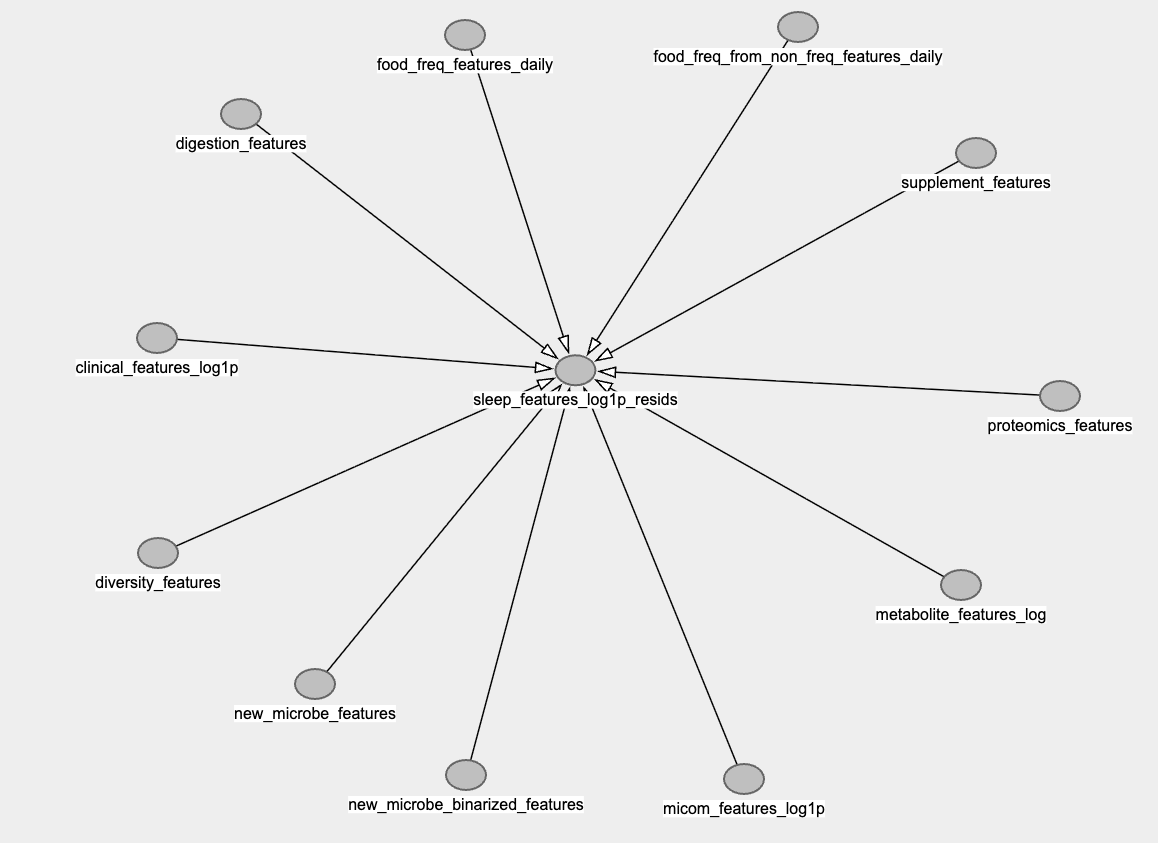

In [29]:
# Can take a quick look at the full regression_configs dict
regression_configs

{'diet_daily_features_to_sleep_features_log1p_resids': {'independent_features': ['diet_freq_alcohol_daily',
   'diet_freq_water_daily',
   'diet_freq_caffeinated_beverages_daily',
   'diet_freq_breakfast_daily',
   'diet_freq_cruciferous_vegetables_daily',
   'diet_freq_snacking_daily',
   'diet_freq_fresh_fruit_daily',
   'diet_freq_raw_vegetables_salad_daily',
   'diet_freq_soft_drinks_daily',
   'diet_freq_beans_legumes_daily',
   'diet_freq_breakfast_cereal_daily',
   'diet_freq_cheese_daily',
   'diet_freq_cook_home_daily',
   'diet_freq_cooked_green_vegetables_daily',
   'diet_freq_cooked_root_vegetables_daily',
   'diet_freq_eating_out_daily',
   'diet_freq_eggs_daily',
   'diet_freq_french_fries_daily',
   'diet_freq_fruit_juice_daily',
   'diet_freq_ice_cream_daily',
   'diet_freq_meat_daily',
   'diet_freq_nuts_seeds_daily',
   'diet_freq_oil_rich_fish_daily',
   'diet_freq_pastries_daily',
   'diet_freq_plant_based_protein_daily',
   'diet_freq_potatoes_pasta_rice_daily',
  

## Fitting the UNADJUSTED regression configs 10-15-2025

NOTE!! Both the supplements and binarized microbes are IV binary variables, but will NOT specify them with C() in the regression formulas. Patsy does this automatically

In [30]:
from statsmodels.stats.multitest import multipletests

# Output directory for regressions
output_dir = 'lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/'
# Error file output directory
error_output_dir = 'lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/error_outputs/'

# Run each regression config
for config_name, config in regression_configs.items():
    
    # Name the output file to save the results
    filename = f"{output_dir}{config_name}_unadjusted_10-15-2025.csv"

    # Check if file already exists
    if os.path.exists(filename):
        print(f"Skipping {filename} (already exists)")
        continue  # skip to next iteration

    print(f"Running {config_name}")
    
    # Run regression
    regressions, error_file = linear_regression_results(
        dependent_features=config['dependent_features'],
        independent_features=config['independent_features'],
        drop_subset_list=config['columns_to_drop_on'],
        formula_string=config['formula'],
        df=sleep_merged,
        test_df=sleep_merged,
        model_type=config['model_type'],
        categorical_poly=config['categorical_poly']
    )

    try:
        # Apply FDR correction
        regressions = regressions.groupby('dependent_feature').apply(
            lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
        ).reset_index(drop=True)
    
        # Save to CSV
        filename = f'{output_dir}{config_name}_unadjusted_10-15-2025.csv'
        regressions.to_csv(filename, index=False)
        error_filename = f'{error_output_dir}{config_name}_unadjusted_error_log_10-15-2025.csv'
        error_file.to_csv(error_filename, index=False)
        print(f'Saved: {filename}')

    except:
        # Save to CSV
        filename = f'{output_dir}{config_name}_unadjusted_FDR_ERROR_10-15-2025.csv'
        regressions.to_csv(filename, index=False)
        error_filename = f'{error_output_dir}{config_name}_unadjusted_error_log_FDR_ERROR_10-15-2025.csv'
        error_file.to_csv(error_filename, index=False)
        print(f'Saved: {filename}')
        print(f'Couldnt apply FDR correction, {output_dir}{config_name}_unadjusted_10-15-2025.csv is probably empty')

Skipping lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/diet_daily_features_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv (already exists)
Skipping lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/supplement_features_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv (already exists)
Skipping lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/digestion_features_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv (already exists)
Running new_microbe_features_to_sleep_features_log1p_resids
This is microbe regression
Saved: lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/new_microbe_features_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv
Running new_microbe_binarized_features_to_sleep_features_log1p_resids
This is microbe regression
Saved: lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/new_microbe_binarized_features_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv
Running diversity_features_to_sleep_features_log1p_re

### Update MICOM tests so that FDR isn't inflated, there's duplicate MICOM columns, see below

Check 10-08-2025-merging_dfs_onto_cleaned_fitbit_Scheme26.ipynb file under the "Add in MICOM Predicted Metabolites" tab: 4 of the MICOM columns are identical. They are all rare sugars of rhamnogalacturonan II. Listed in the regression MICOM test df as entries under "independent_feature" column, only keep 1 of the 4 different test entries and discard the rest since they are the same. Identical columns:
- micom_9: '2-o-methylfucose (rare sugar in rhamnogalacturonan II)',
- micom_10: '2-O-methylxylose (rare sugar in rhamnogalacturonan II)',
- micom_11: '3-deoxy-d-lyxo-heptulosaric acid (rare sugar in rhamnogalacturonan II)',
- micom_129: '3-Deoxy-D-manno-2-octulosonate'

In [142]:
import pandas as pd
micom_tests_unadjusted = pd.read_csv('lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/micom_features_log_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv')

In [116]:
# Open the dict with the micom codes to names
with open('../independent_feature_dataframes/micom_features_codes_to_names.json', 'r') as f:
    micom_name_dict = json.load(f)

In [118]:
micom_name_dict['micom_9']

'2-o-methylfucose (rare sugar in rhamnogalacturonan II)'

In [119]:
micom_name_dict['micom_10']

'2-O-methylxylose (rare sugar in rhamnogalacturonan II)'

In [120]:
micom_name_dict['micom_11']

'3-deoxy-d-lyxo-heptulosaric acid (rare sugar in rhamnogalacturonan II)'

In [121]:
micom_name_dict['micom_129']

'3-Deoxy-D-manno-2-octulosonate'

In [122]:
# Just keep one, we'll save micom_9_log rows, and drop any rows containing 10, 11, or 129. Then re-compute q values
micom_tests_unadjusted = micom_tests_unadjusted[~micom_tests_unadjusted.independent_feature.str.contains('micom_10_log|micom_11_log|micom_129_log')]

### Turns out some columns are perfectly linear (same data, different scales). Let's identify those and then see if we can collapse some results

In [143]:
import numpy as np
import pandas as pd

# Compute correlation matrix
corr = sleep_merged[micom_tests_unadjusted.independent_feature.unique()].corr(method='pearson')

# Remove diagonal
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

# Keep only upper triangle to avoid duplicate pairs
upper_triangle = corr_no_diag.where(
    np.triu(np.ones(corr_no_diag.shape), k=1).astype(bool)
)

# Find perfectly linear relationships
perfect_pairs = (
    upper_triangle
    .stack()
    .loc[lambda x: np.isclose(x, 1) | np.isclose(x, -1)]
)

results = pd.DataFrame({
    "Column_1": perfect_pairs.index.get_level_values(0),
    "Column_2": perfect_pairs.index.get_level_values(1),
    "Correlation": perfect_pairs.values
})

results.reset_index(drop=True)

,Column_1,Column_2,Correlation
0,micom_25_log,micom_50_log,1.000000
1,micom_39_log,micom_73_log,0.999998


In [124]:
flat = pd.unique(
    np.concatenate(perfect_pairs.index.to_list())
).tolist()

In [125]:
for col in flat:
    print(f'{col}: {micom_name_dict[col[:-4]]}')
    print('')

micom_25_log: lithocholate

micom_50_log: Allolithocholic acid

micom_33_log: Aceric acid (3-C-carboxy-5-deoxy-l-xylose) (rare sugar in rhamnogalacturonan II)

micom_51_log: D-Apiose (rare sugar in rhamnogalacturonan II)

micom_9_log: 2-o-methylfucose (rare sugar in rhamnogalacturonan II)

micom_39_log: Allodeoxycholic acid

micom_73_log: deoxycholic acid



In [126]:
sleep_merged[flat].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469 entries, 0 to 1468
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   micom_25_log  141 non-null    float64
 1   micom_50_log  134 non-null    float64
 2   micom_33_log  1445 non-null   float64
 3   micom_51_log  1445 non-null   float64
 4   micom_9_log   1445 non-null   float64
 5   micom_39_log  381 non-null    float64
 6   micom_73_log  525 non-null    float64
dtypes: float64(7)
memory usage: 80.5 KB


In [127]:
# Is the missingness in all the same people for the micom 33, 51, and 9 columns, aka RG II columns?
# Show the missingness patterns and how many rows fall into each pattern
rg_II_cols = ["micom_33_log", "micom_51_log", "micom_9_log"]

patterns = sleep_merged[rg_II_cols].isna().value_counts()
patterns

micom_33_log  micom_51_log  micom_9_log
False         False         False          1445
True          True          True             24
Name: count, dtype: int64

^^^ All the RG II missingness is in the same people, so it will be safe to collapse these results into 1. We will leave the rest alone since there is varying missingness. Let's drop all MICOM 51 and 33 rows as well and recompute q values.

In [128]:
# Just keep one, we'll save micom_9_log rows, and drop any rows containing 10, 11, or 129. Then re-compute q values
micom_tests_unadjusted = micom_tests_unadjusted[~micom_tests_unadjusted.independent_feature.str.contains('micom_33_log|micom_51_log')]

from statsmodels.stats.multitest import multipletests
micom_tests_unadjusted = micom_tests_unadjusted.groupby('dependent_feature').apply(
            lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
        ).reset_index(drop=True)

In [129]:
# Save the new unadjusted test set with updated q values
micom_tests_unadjusted.to_csv('lifestyle_and_omics_on_sleep_and_unadjusted_10-15-2025/micom_features_log_to_sleep_features_log1p_resids_unadjusted_10-15-2025.csv', index=False)

## Specify the ADJUSTED regression configs 10-15-2025

In [31]:
# Generate the regression_configs dictionary using the layered_sources nested list, which is a representation of the DAG

regression_configs = {}

for i, source_layer in enumerate(layered_sources[:-1]):
    # Extract the source info
    for source in source_layer:
        source_group = find_feature_group(source, feature_groups)
        if source_group is None:
            print(f"❗ Warning: Couldn't find group for source '{source}'")
        source_vendor = feature_groups.get(source_group, {}).get("vendor", {})
        source_dip = feature_groups.get(source_group, {}).get("dip", {})

        # use i+1 to jump to the next layer in the layered_sources list
        for j in range(i + 1, len(layered_sources)):
            # Extract the target info
            for target in layered_sources[j]:
                target_group = find_feature_group(target, feature_groups)
                if target_group is None:
                    print(f"❗ Warning: Couldn't find group for target '{target}'")
                target_vendor = feature_groups.get(target_group, {}).get("vendor", {})
                target_dip = feature_groups.get(target_group, {}).get("dip", {})
                
                config_name = f"{source}_to_{target}"

                # Construct diff dip name based on naming convention
                diff_dip = f"{target_dip}_minus_{source_dip}"
                extra_covariates = [diff_dip]

                # Combine sex + vendor(s), if any
                cat_covs = ["sex", "any_mental_health_self_anytime_before", "any_sleep_disorder_self_anytime_before", "mental_health_gut_sleep_q_vendor"]
                if source_vendor:
                    cat_covs.append(source_vendor)
                if target_vendor and target_vendor not in cat_covs:
                    cat_covs.append(target_vendor)

                # Determine model_type
                model_type = "linear"
                if target == "happiness_features_collapsed":
                    model_type = "ordinal"

                if target == "new_microbe_features_binary_10_90":
                    model_type = "logistic"

                # Determine whether categorical_poly should be true
                categorical_poly = False
                if source == "digestion_features":
                    categorical_poly = True
                
                # Construct diff dip name based on naming convention
                diff_dip = [f"{target_dip}_minus_{source_dip}"]
                
                # Update regression_configs
                regression_configs.update(build_regression_config(
                    name=config_name,
                    independent_features=features_dict[source],
                    dependent_features=features_dict[target],
                    base_covariates=features_dict["covariate_features"][1:],
                    extra_covariates=diff_dip + ["activities_activityCalories_resid", "activities_steps_resid", "activities_floors_resid", "avg_stress"],
                    categorical_covariates=cat_covs,
                    model_type=model_type,
                    categorical_poly=categorical_poly
                ))
                # Print to ensure for loops are behaving as intended
                print('New source-target config')
                print(source_group)
                print(source_vendor)
                print(source_dip)
                print('')
                print(target_group)
                print(target_vendor)
                print(target_dip)
                print('')
                print('')

New source-target config
diet_group
{}
diet_dip

fitbit_group
{}
fitbit_dip


New source-target config
supplements_group
supp_meds_vendor
supp_meds_dip

fitbit_group
{}
fitbit_dip


New source-target config
digestion_group
digestion_vendor
digestion_dip

fitbit_group
{}
fitbit_dip


New source-target config
microbiome_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitbit_dip


New source-target config
microbiome_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitbit_dip


New source-target config
diversity_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitbit_dip


New source-target config
clinical_group
clinical_vendor
clinical_dip

fitbit_group
{}
fitbit_dip


New source-target config
metabolite_group
{}
metabolite_dip

fitbit_group
{}
fitbit_dip


New source-target config
proteome_group
{}
proteomics_dip

fitbit_group
{}
fitbit_dip


New source-target config
micom_metab_group
microbiome_vendor
reference_microbe_dip

fitbit_group
{}
fitb

In [32]:
# Loop through the values in the regression_configs dict we just made to make sure everything was input correctly
for config in regression_configs.keys():
    print(config)
    print(regression_configs[config]['formula'])
    print(regression_configs[config]['columns_to_drop_on'])
    print(regression_configs[config]['model_type'])
    print(regression_configs[config]['categorical_poly'])
    print('')

diet_daily_features_to_sleep_features_log1p_resids
{dependent_feature} ~ {independent_feature} + age + BMI_CALC + PC1 + PC2 + PC3 + C(sex) + C(any_mental_health_self_anytime_before) + C(any_sleep_disorder_self_anytime_before) + C(mental_health_gut_sleep_q_vendor) + fitbit_dip_minus_diet_dip + activities_activityCalories_resid + activities_steps_resid + activities_floors_resid + avg_stress
['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'any_mental_health_self_anytime_before', 'any_sleep_disorder_self_anytime_before', 'mental_health_gut_sleep_q_vendor', 'fitbit_dip_minus_diet_dip', 'activities_activityCalories_resid', 'activities_steps_resid', 'activities_floors_resid', 'avg_stress']
linear
False

supplement_features_to_sleep_features_log1p_resids
{dependent_feature} ~ {independent_feature} + age + BMI_CALC + PC1 + PC2 + PC3 + C(sex) + C(any_mental_health_self_anytime_before) + C(any_sleep_disorder_self_anytime_before) + C(mental_health_gut_sleep_q_vendor) + C(supp_meds_vendor) + fitbit

In [33]:
# How many different regression configs?
len(regression_configs.keys())

10

In [34]:
# Great and it looks like they're all unique, no redundancy!
len(set(regression_configs.keys()))

10

In [35]:
# Now we can generate a DAG that represents all our source-target regression sets in regression_configs
# Copy/paste the output into daggity.net to see the graph

# Use all the keys from regression_configs as the source and target variable names
regression_configs_daggity = list(regression_configs.keys())

edges = []
nodes = set()

for config in regression_configs_daggity:
    if "_to_" in config:
        source, target = config.split("_to_")
        nodes.add(source)
        nodes.add(target)
        edges.append(f'"{source}" -> "{target}"')

# Format into daggity format
daggity_text = "dag {\n"
for node in sorted(nodes):
    daggity_text += f'"{node}"\n'
for edge in edges:
    daggity_text += f"{edge}\n"
daggity_text += "}"

print(daggity_text)

dag {
"clinical_features_log1p"
"diet_daily_features"
"digestion_features"
"diversity_features"
"metabolite_features_log"
"micom_features_log"
"new_microbe_binarized_features"
"new_microbe_features"
"proteomics_features"
"sleep_features_log1p_resids"
"supplement_features"
"diet_daily_features" -> "sleep_features_log1p_resids"
"supplement_features" -> "sleep_features_log1p_resids"
"digestion_features" -> "sleep_features_log1p_resids"
"new_microbe_features" -> "sleep_features_log1p_resids"
"new_microbe_binarized_features" -> "sleep_features_log1p_resids"
"diversity_features" -> "sleep_features_log1p_resids"
"clinical_features_log1p" -> "sleep_features_log1p_resids"
"metabolite_features_log" -> "sleep_features_log1p_resids"
"proteomics_features" -> "sleep_features_log1p_resids"
"micom_features_log" -> "sleep_features_log1p_resids"
}


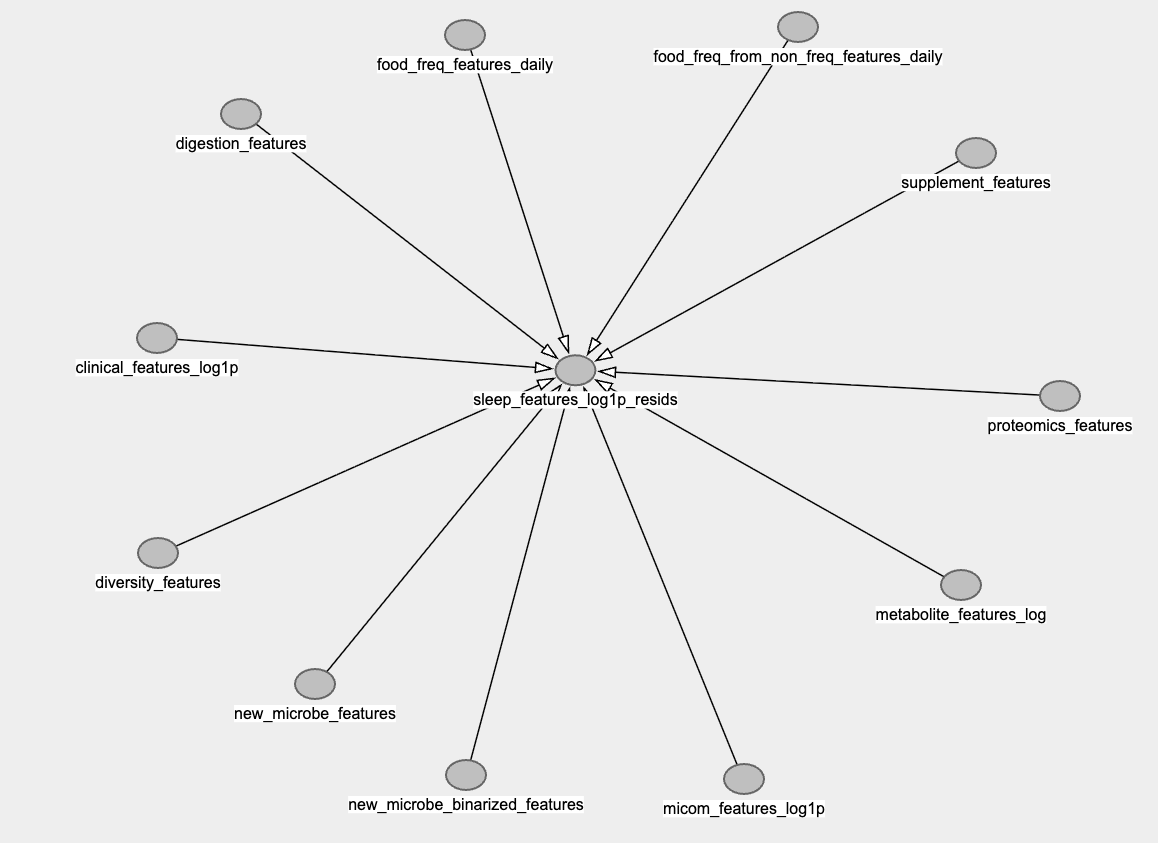

In [36]:
# Can take a quick look at the full regression_configs dict
regression_configs

{'diet_daily_features_to_sleep_features_log1p_resids': {'independent_features': ['diet_freq_alcohol_daily',
   'diet_freq_water_daily',
   'diet_freq_caffeinated_beverages_daily',
   'diet_freq_breakfast_daily',
   'diet_freq_cruciferous_vegetables_daily',
   'diet_freq_snacking_daily',
   'diet_freq_fresh_fruit_daily',
   'diet_freq_raw_vegetables_salad_daily',
   'diet_freq_soft_drinks_daily',
   'diet_freq_beans_legumes_daily',
   'diet_freq_breakfast_cereal_daily',
   'diet_freq_cheese_daily',
   'diet_freq_cook_home_daily',
   'diet_freq_cooked_green_vegetables_daily',
   'diet_freq_cooked_root_vegetables_daily',
   'diet_freq_eating_out_daily',
   'diet_freq_eggs_daily',
   'diet_freq_french_fries_daily',
   'diet_freq_fruit_juice_daily',
   'diet_freq_ice_cream_daily',
   'diet_freq_meat_daily',
   'diet_freq_nuts_seeds_daily',
   'diet_freq_oil_rich_fish_daily',
   'diet_freq_pastries_daily',
   'diet_freq_plant_based_protein_daily',
   'diet_freq_potatoes_pasta_rice_daily',
  

## Fitting the ADJUSTED regression configs 10-15-2025

In [37]:
# from statsmodels.stats.multitest import multipletests

# Output directory for regressions
output_dir = 'lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/'
# Error file output directory
error_output_dir = 'lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/error_outputs/'

# Run each regression config
for config_name, config in regression_configs.items():
    
    # Name the output file to save the results
    filename = f"{output_dir}{config_name}_adjusted_10-15-2025.csv"

    # Check if file already exists
    if os.path.exists(filename):
        print(f"Skipping {filename} (already exists)")
        continue  # skip to next iteration

    print(f"Running {config_name}")
    
    # Run regression
    regressions, error_file = linear_regression_results(
        dependent_features=config['dependent_features'],
        independent_features=config['independent_features'],
        drop_subset_list=config['columns_to_drop_on'],
        formula_string=config['formula'],
        df=sleep_merged,
        test_df=sleep_merged,
        model_type=config['model_type'],
        categorical_poly=config['categorical_poly']
    )

    try:
        # Apply FDR correction
        regressions = regressions.groupby('dependent_feature').apply(
            lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
        ).reset_index(drop=True)
    
        # Save to CSV
        filename = f'{output_dir}{config_name}_adjusted_10-15-2025.csv'
        regressions.to_csv(filename, index=False)
        error_filename = f'{error_output_dir}{config_name}_adjusted_error_log_10-15-2025.csv'
        error_file.to_csv(error_filename, index=False)
        print(f'Saved: {filename}')

    except:
        # Save to CSV
        filename = f'{output_dir}{config_name}_adjusted_FDR_ERROR_10-15-2025.csv'
        regressions.to_csv(filename, index=False)
        error_filename = f'{error_output_dir}{config_name}_adjusted_error_log_FDR_ERROR_10-15-2025.csv'
        error_file.to_csv(error_filename, index=False)
        print(f'Saved: {filename}')
        print(f'Couldnt apply FDR correction, {output_dir}{config_name}_adjusted_10-15-2025.csv is probably empty')

Skipping lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/diet_daily_features_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv (already exists)
Skipping lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/supplement_features_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv (already exists)
Skipping lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/digestion_features_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv (already exists)
Running new_microbe_features_to_sleep_features_log1p_resids
This is microbe regression
Saved: lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/new_microbe_features_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv
Running new_microbe_binarized_features_to_sleep_features_log1p_resids
This is microbe regression
Saved: lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/new_microbe_binarized_features_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv
Running diversity_features_to_sleep_features_log1p_resids
This is microbe

### SAME AS ABOVE, Update MICOM tests so that FDR isn't inflated, there's duplicate MICOM columns, see below

In [145]:
import pandas as pd
micom_tests_adjusted = pd.read_csv('lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/micom_features_log_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv')

In [146]:
# Just keep one, we'll save micom_9_log rows, and drop any rows containing 10, 11, or 129. Then re-compute q values
micom_tests_adjusted = micom_tests_adjusted[~micom_tests_adjusted.independent_feature.str.contains('micom_10_log|micom_11_log|micom_129_log')]

### Let's check for perfectly linear entries like above in the unadjusted MICOM, probably the same as above, RG II sugars

In [147]:
import numpy as np
import pandas as pd

# Compute correlation matrix
corr = sleep_merged[micom_tests_adjusted.independent_feature.unique()].corr(method='pearson')

# Remove diagonal
corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

# Keep only upper triangle to avoid duplicate pairs
upper_triangle = corr_no_diag.where(
    np.triu(np.ones(corr_no_diag.shape), k=1).astype(bool)
)

# Find perfectly linear relationships
perfect_pairs = (
    upper_triangle
    .stack()
    .loc[lambda x: np.isclose(x, 1) | np.isclose(x, -1)]
)

results = pd.DataFrame({
    "Column_1": perfect_pairs.index.get_level_values(0),
    "Column_2": perfect_pairs.index.get_level_values(1),
    "Correlation": perfect_pairs.values
})

results.reset_index(drop=True)

,Column_1,Column_2,Correlation
0,micom_33_log,micom_51_log,1.000000
1,micom_33_log,micom_9_log,1.000000
2,micom_39_log,micom_73_log,0.999998
3,micom_51_log,micom_9_log,1.000000


In [148]:
flat = pd.unique(
    np.concatenate(perfect_pairs.index.to_list())
).tolist()

In [149]:
for col in flat:
    print(f'{col}: {micom_name_dict[col[:-4]]}')
    print('')

micom_33_log: Aceric acid (3-C-carboxy-5-deoxy-l-xylose) (rare sugar in rhamnogalacturonan II)

micom_51_log: D-Apiose (rare sugar in rhamnogalacturonan II)

micom_9_log: 2-o-methylfucose (rare sugar in rhamnogalacturonan II)

micom_39_log: Allodeoxycholic acid

micom_73_log: deoxycholic acid



### It's the same MICOM columns as above, let's drop the entries as we did before

In [150]:
# Just keep one, we'll save micom_9_log rows, and drop any rows containing 10, 11, or 129. Then re-compute q values
micom_tests_adjusted = micom_tests_adjusted[~micom_tests_adjusted.independent_feature.str.contains('micom_33_log|micom_51_log')]

from statsmodels.stats.multitest import multipletests
micom_tests_adjusted = micom_tests_adjusted.groupby('dependent_feature').apply(
            lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
        ).reset_index(drop=True)

In [151]:
micom_tests_adjusted.to_csv('lifestyle_and_omics_on_sleep_and_adjusted_10-15-2025/micom_features_log_to_sleep_features_log1p_resids_adjusted_10-15-2025.csv', index=False)